In [9]:
import json
import ast
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler,RobustScaler

In [10]:
df = pd.read_csv("model_features.csv")

In [11]:
def column_stats(df):
    stats = []

    for col in df.columns:
        if pd.api.types.is_numeric_dtype(df[col]):
            s = df[col].dropna()

            stats.append({
                'column': col,
                'min': s.min(),
                'max': s.max(),
                'mean': s.mean(),
                'median': s.median(),
                'std': s.std(),
                'skew': s.skew(),
                'kurtosis': s.kurt(),
                'q1': s.quantile(0.25),
                'q3': s.quantile(0.75),
                'iqr': s.quantile(0.75) - s.quantile(0.25),
                'zero_ratio': (s == 0).mean(),
                'unique': s.nunique()
            })

    return pd.DataFrame(stats).sort_values(by='skew', ascending=False)

In [12]:
stats_df = column_stats(df)

In [13]:
stats_df.head(60)

,column,min,max,mean,median,std,skew,kurtosis,q1,q3,iqr,zero_ratio,unique
51,total_views_recent,2068.000000,9.634141e+08,3.153143e+06,1.194663e+06,1.477170e+07,54.500358,3513.496524,5.056890e+05,2.825687e+06,2.319998e+06,0.000000,5087
52,total_hearts_recent,0.000000,2.584405e+07,3.067029e+04,3.040000e+03,4.177759e+05,52.229331,3033.642705,6.760000e+02,1.192100e+04,1.124500e+04,0.000590,3950
11,followersGrowthRate,-0.154088,4.203700e+04,1.737741e+01,3.702500e-03,8.132967e+02,50.221039,2530.924471,-1.874414e-03,3.110764e-02,3.298206e-02,0.001965,5080
55,max_view_recent,495.000000,2.509662e+08,1.104868e+06,3.659750e+05,4.178282e+06,43.081724,2519.160121,1.343280e+05,1.001048e+06,8.667200e+05,0.000000,5078
40,country_KR,0.000000,4.889027e-01,2.733627e-03,0.000000e+00,9.177007e-03,32.311099,1579.565549,0.000000e+00,4.400282e-03,4.400282e-03,0.575162,2163
2,recommendRate100k,0.000000,7.161373e+13,3.811879e+11,1.226300e+11,1.356064e+12,31.223297,1520.516829,4.466247e+10,3.299726e+11,2.853101e+11,0.003537,4460
1,startingRate100k,0.000000,1.150000e+14,3.160794e+11,0.000000e+00,3.371246e+12,28.420379,863.928597,0.000000e+00,1.000000e+11,1.000000e+11,0.644331,203
38,country_JP,0.000000,4.936800e-01,4.755977e-03,1.748119e-03,1.550758e-02,19.471318,480.669404,0.000000e+00,6.612571e-03,6.612571e-03,0.460798,2745
39,country_TW,0.000000,5.832739e-01,5.779939e-03,1.861944e-03,1.907594e-02,17.633849,435.908577,0.000000e+00,6.840620e-03,6.840620e-03,0.451562,2792
42,country_KH,0.000000,9.195298e-01,7.321621e-03,0.000000e+00,3.906105e-02,15.098860,288.770259,0.000000e+00,3.202293e-03,3.202293e-03,0.660641,1728


(array([  13.,   13.,   53.,  245.,  688., 1430., 1519.,  771.,  288.,
          69.]),
 array([-1.        , -0.84218112, -0.68436224, -0.52654337, -0.36872449,
        -0.21090561, -0.05308673,  0.10473215,  0.26255102,  0.4203699 ,
         0.57818878]),
 <BarContainer object of 10 artists>)

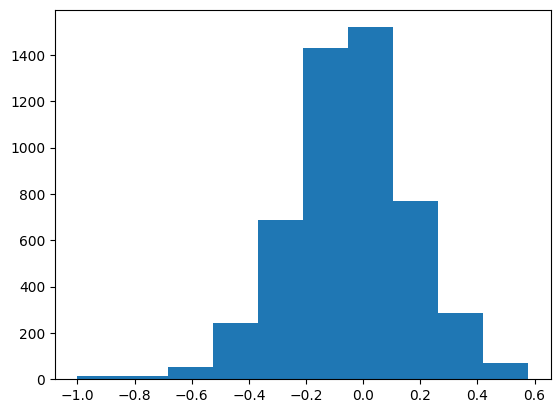

In [14]:
plt.hist(df['burstiness_recent'])

In [15]:
df.columns

Index(['handleName', 'followerCnt', 'startingRate100k', 'recommendRate100k',
       'followersGrowthRateRank', 'avgSixSecondsViewsRateRank',
       'medianViewsRank', 'videoCompleteRateRank', 'engagementRateRank',
       'avgSixSecondsViewsBenchMarkViews', 'medianBenchMarkViews',
       'engagementRateBenchMark', 'followersGrowthRate',
       'avgSixSecondsViewsRate', 'videoCompleteRate', 'engagementRate',
       'medianViews', 'broadcastingScore', 'collaborationScore',
       'commercialScore', 'active_active', 'active_inactive', 'age_18-24',
       'age_25-34', 'age_13-17', 'age_35-44', 'age_55+', 'age_45-54',
       'age_Other', 'device_APPLE', 'device_SAMSUNG', 'device_OPPO',
       'device_XIAOMI', 'device_VIVO', 'device_Other', 'gender_Female',
       'gender_Male', 'country_VN', 'country_US', 'country_JP', 'country_TW',
       'country_KR', 'country_MM', 'country_KH', 'country_TH', 'country_PH',
       'country_ID', 'Beauty', 'Education', 'Entertainment', 'Food', 'Sports',
     

In [16]:
# =========================
# 1) Khai báo các nhóm cột
# =========================
right_skew_log_cols = [
    'startingRate100k', 'recommendRate100k', 'total_views_recent',
    'max_view_recent', 'total_hearts_recent', 'followerCnt',
    'median_view_recent', 'medianViews', 'medianBenchMarkViews',
    'total_comments_recent', 'recency_days_recent'
]

right_skew_log1p_cols = [
    'followersGrowthRate'
]

left_skew_cols = [
    'broadcastingScore','collaborationScore','commercialScore', 
]



In [17]:

# =========================
# 2) Hàm hỗ trợ
# =========================
def winsor_clip(s, lower_q=0.01, upper_q=0.99):
    """
    Winsorize bằng cách clip theo quantile.
    """
    s = pd.to_numeric(s, errors='coerce')
    q_low = s.quantile(lower_q)
    q_high = s.quantile(upper_q)
    return s.clip(lower=q_low, upper=q_high)

def safe_log(s):
    """
    Log an toàn:
    - Nếu có giá trị <= 0 thì shift lên để toàn bộ > 0 rồi mới log
    """
    s = pd.to_numeric(s, errors='coerce')
    min_val = s.min(skipna=True)
    
    if pd.isna(min_val):
        return s
    
    shift = 0
    if min_val <= 0:
        shift = 1 - min_val   # để min sau shift = 1
    
    return np.log(s + shift)

def safe_log1p(s):
    """
    Log1p an toàn:
    - Nếu có giá trị <= -1 thì shift lên để toàn bộ > -1 rồi mới log1p
    """
    s = pd.to_numeric(s, errors='coerce')
    min_val = s.min(skipna=True)
    
    if pd.isna(min_val):
        return s
    
    shift = 0
    if min_val <= -1:
        shift = (-min_val) + 1e-6
    
    return np.log1p(s + shift)

def left_skew_transform(s):
    """
    Xử lý lệch trái:
    1) winsorize
    2) reflect: x_ref = max(x) - x
    3) log1p
    4) standardize
    5) đảo dấu lại để giữ chiều diễn giải gần với biến gốc
    """
    s = pd.to_numeric(s, errors='coerce')
    
    # Reflect để biến lệch trái thành gần giống lệch phải
    x_ref = s.max(skipna=True) - s
    
    # tránh 0 hoàn toàn cũng không sao với log1p, nên dùng log1p luôn
    x_log = np.sqrt(x_ref)
    
    return x_log

def standardize_series(s):
    """
    Standardize 1 cột, giữ NaN nguyên vị trí.
    """
    scaler = StandardScaler()
    values = s.values.reshape(-1, 1)
    
    mask = ~np.isnan(values).ravel()
    out = np.full_like(values, np.nan, dtype=float)
    
    if mask.sum() > 0:
        out[mask] = scaler.fit_transform(values[mask].reshape(-1, 1))
    
    return pd.Series(out.ravel(), index=s.index)

def robust(s):
    """
    Standardize 1 cột, giữ NaN nguyên vị trí.
    """
    scaler = RobustScaler()
    values = s.values.reshape(-1, 1)
    
    mask = ~np.isnan(values).ravel()
    out = np.full_like(values, np.nan, dtype=float)
    
    if mask.sum() > 0:
        out[mask] = scaler.fit_transform(values[mask].reshape(-1, 1))
    
    return pd.Series(out.ravel(), index=s.index)
# =========================
# 3) Hàm xử lý toàn bộ df
# =========================
def transform_skewed_features(
    df,
    lower_q=0.01,
    upper_q=0.99,
    add_suffix=True
):
    """
    Xử lý các cột lệch dữ liệu theo rule đã định.
    
    add_suffix=True:
        tạo cột mới dạng *_trans
    add_suffix=False:
        ghi đè lên cột cũ
    """
    df_out = df.copy()

    # --- nhóm: winsor + log + standardize ---
    for col in right_skew_log_cols:
        if col in df_out.columns:
            s = winsor_clip(df_out[col], lower_q, upper_q)
            s = safe_log(s)
            s = standardize_series(s)

            new_col = f"{col}_trans" if add_suffix else col
            df_out[new_col] = s

    # --- nhóm: winsor + log1p + standardize ---
    for col in right_skew_log1p_cols:
        if col in df_out.columns:
            s = winsor_clip(df_out[col], lower_q, upper_q)
            s = safe_log1p(s)
            s = standardize_series(s)

            new_col = f"{col}_trans" if add_suffix else col
            df_out[new_col] = s

    # --- nhóm: lệch trái ---
    for col in left_skew_cols:
        if col in df_out.columns:
            s = robust(df_out[col])
            # đảo dấu để giữ ý nghĩa chiều gần giống biến gốc
            s = -s

            new_col = f"{col}_trans" if add_suffix else col
            df_out[new_col] = s

    return df_out


In [18]:

# =========================
# 4) Chạy trên df
# =========================
df_processed = transform_skewed_features(
    df,
    lower_q=0.01,   # bạn có thể đổi 0.005 hoặc 0.02
    upper_q=0.99,
    add_suffix=False # True = giữ cột gốc, tạo cột mới
)

cols_done = right_skew_log_cols + right_skew_log1p_cols + left_skew_cols
cols_done = [c for c in cols_done if c in df_processed.columns]

print(cols_done)
print(df_processed[cols_done].head())

['startingRate100k', 'recommendRate100k', 'total_views_recent', 'max_view_recent', 'total_hearts_recent', 'followerCnt', 'median_view_recent', 'medianViews', 'medianBenchMarkViews', 'total_comments_recent', 'recency_days_recent', 'followersGrowthRate', 'broadcastingScore', 'collaborationScore', 'commercialScore']
   startingRate100k  recommendRate100k  total_views_recent  max_view_recent  \
0          1.551280           1.206644           -0.340921        -0.340029   
1         -0.737146           1.501161            2.102047         1.848568   
2         -0.737146           1.254545            0.320244        -0.369363   
3         -0.737146           1.093150            1.060869         1.146435   
4         -0.737146           1.923259            0.935382         0.668147   

   total_hearts_recent  followerCnt  median_view_recent  medianViews  \
0             0.359238     2.467623            0.036979     0.183460   
1             2.356263     1.927133            1.993098    -0.8838

In [ ]:
# =========================
# 1. Channel size
# =========================
channel_size_cols = [
    'followerCnt', 
    'startingRate100k', # người dùng tự set giá cho mình
    'recommendRate100k',  # nền tảng đề xuất cho người dùng 
]

# =========================
# 2. Rank features
# =========================
rank_cols = [
    'followersGrowthRateRank',
    'avgSixSecondsViewsRateRank',
    'medianViewsRank',
    'videoCompleteRateRank',
    'engagementRateRank'
]

# =========================
# 3. Benchmark features
# =========================
benchmark_cols = [
    'avgSixSecondsViewsBenchMarkViews', 
    'medianBenchMarkViews',
    'engagementRateBenchMark'
]

# =========================
# 4. Performance 
# =========================
performance_cols = [
    'followersGrowthRate',
    'avgSixSecondsViewsRate',
    'videoCompleteRate',
    'engagementRate',
    'medianViews',
    'broadcastingScore',
    'collaborationScore',
    'commercialScore',
    
    
]

# =========================
# 5. Audience distribution
# =========================
audience_cols = [
    'active_active', 'active_inactive',
    'age_18-24', 'age_25-34', 'age_13-17',
    'age_35-44', 'age_55+', 'age_45-54', 'age_Other',
    'device_APPLE', 'device_SAMSUNG', 'device_OPPO',
    'device_XIAOMI', 'device_VIVO', 'device_Other',
    'gender_Female', 'gender_Male',
    'country_VN', 'country_US', 'country_JP', 'country_TW',
    'country_KR', 'country_MM', 'country_KH',
    'country_TH', 'country_PH', 'country_ID'
]

# =========================
# 6. Content group (one-hot)
# =========================
content_cols = [
    'Beauty', 'Education', 'Entertainment', 'Food', 'Sports'
]

# =========================
# 7. Performance recent (từ 15 video gần nhất)
# =========================
performance_recent_cols = [
    'total_views_recent',        # quy mô kết quả gần đây
    'total_hearts_recent',       # tương tác tổng
    'total_comments_recent',


    'median_view_recent',        # hiệu suất điển hình
    'max_view_recent',           # khả năng bùng nổ

    'cov_view_recent',

    'burstiness_recent',
    'recency_days_recent'

]


In [27]:
df1= df [right_skew_log_cols]


In [21]:
import math
def plot_distribution_2fig(df, bins=30, figsize_hist=(16, 10), figsize_box=(14, 6)):
    """
    Vẽ 2 hình cho DataFrame:
    1) Histogram cho tất cả cột numeric
    2) Boxplot cho tất cả cột numeric
    """
    df_num = df.select_dtypes(include=[np.number]).copy()
    
    if df_num.shape[1] == 0:
        raise ValueError("DataFrame không có cột numeric.")
    
    cols = df_num.columns.tolist()
    
    # Hình 1: Histogram grid
    n = len(cols)
    ncols = 3
    nrows = math.ceil(n / ncols)
    
    fig, axes = plt.subplots(nrows, ncols, figsize=figsize_hist)
    axes = np.array(axes).reshape(-1)
    
    for i, col in enumerate(cols):
        axes[i].hist(df_num[col].dropna(), bins=bins)
        axes[i].set_title(col)
        axes[i].set_xlabel("")
        axes[i].set_ylabel("Count")
    
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])
    
    fig.suptitle("Histogram distributions", y=1.02, fontsize=14)
    plt.tight_layout()
    plt.show()
    
    # Hình 2: Boxplot
    plt.figure(figsize=figsize_box)
    df_num.boxplot(rot=45)
    plt.title("Boxplot distributions")
    plt.tight_layout()
    plt.show()

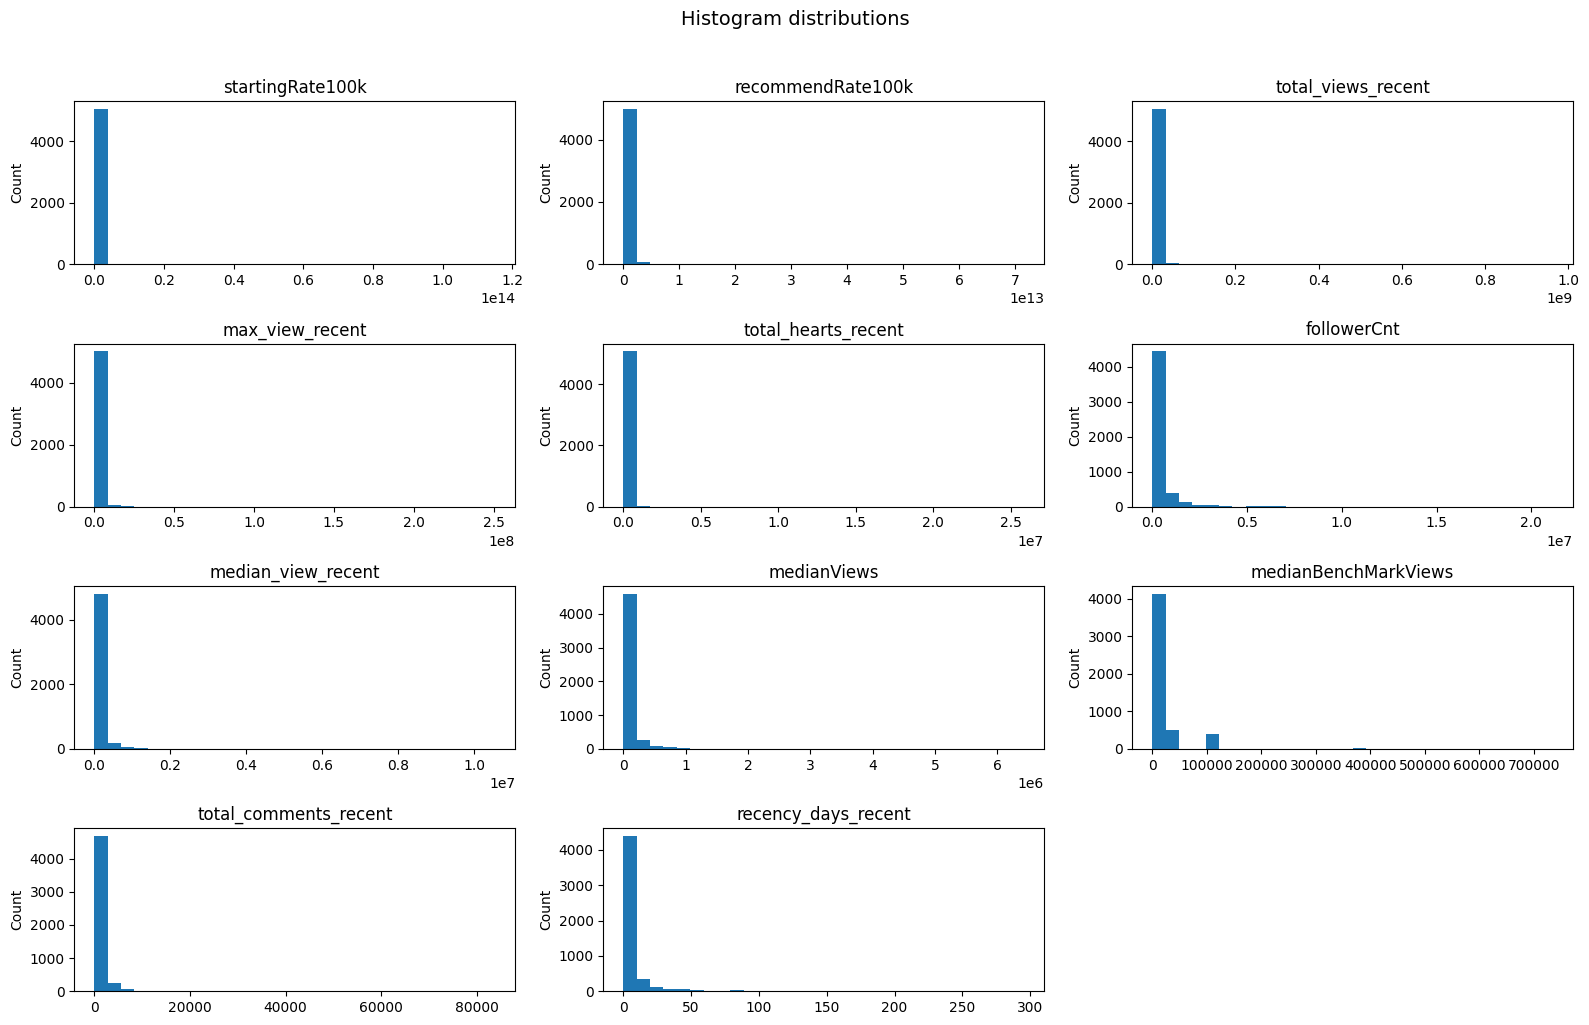

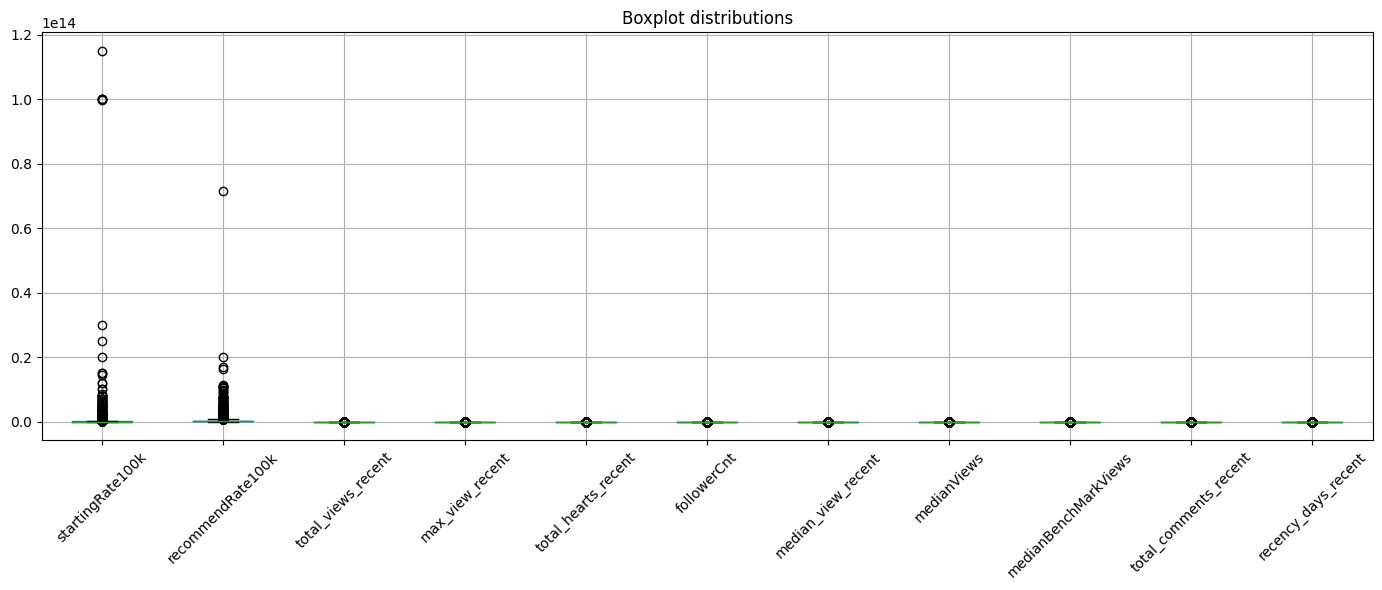

In [28]:
plot_distribution_2fig(df1)


In [23]:
df_processed.columns

Index(['handleName', 'followerCnt', 'startingRate100k', 'recommendRate100k',
       'followersGrowthRateRank', 'avgSixSecondsViewsRateRank',
       'medianViewsRank', 'videoCompleteRateRank', 'engagementRateRank',
       'avgSixSecondsViewsBenchMarkViews', 'medianBenchMarkViews',
       'engagementRateBenchMark', 'followersGrowthRate',
       'avgSixSecondsViewsRate', 'videoCompleteRate', 'engagementRate',
       'medianViews', 'broadcastingScore', 'collaborationScore',
       'commercialScore', 'active_active', 'active_inactive', 'age_18-24',
       'age_25-34', 'age_13-17', 'age_35-44', 'age_55+', 'age_45-54',
       'age_Other', 'device_APPLE', 'device_SAMSUNG', 'device_OPPO',
       'device_XIAOMI', 'device_VIVO', 'device_Other', 'gender_Female',
       'gender_Male', 'country_VN', 'country_US', 'country_JP', 'country_TW',
       'country_KR', 'country_MM', 'country_KH', 'country_TH', 'country_PH',
       'country_ID', 'Beauty', 'Education', 'Entertainment', 'Food', 'Sports',
     

In [24]:
# df_processed.to_csv("model_features_transformed.csv", index=False)